In [111]:
import pandas as pd
from io import StringIO

r_archivos = pd.read_csv('resultados_archivos_var.csv', sep=';')
r_patrones = pd.read_csv('resultados_patrones_var.csv', sep=';')


f_creacion = open('tiempo_de_creacion.csv', 'r') # Crea un archivo vacío si no existe
lineas_tiempo_creacion = f_creacion.readlines()  # Lee el contenido del archivo
t_creacion_archivos = lineas_tiempo_creacion[:-5] # Lee el contenido del archivo
# t_creacion_patrones = lineas_tiempo_creacion[-5:] # Lee el contenido del archivo
f_creacion.close()

str_t_creacion_archivos = ''.join(t_creacion_archivos)  # Convierte la lista de líneas en un string
r_tiempo_creacion_archivos = pd.read_csv(StringIO(str_t_creacion_archivos), sep=';')

<Axes: title={'center': 'Tiempo medio de ejecución por algoritmo y cantidad de archivos'}, xlabel='Archivo', ylabel='Tiempo (ns)'>

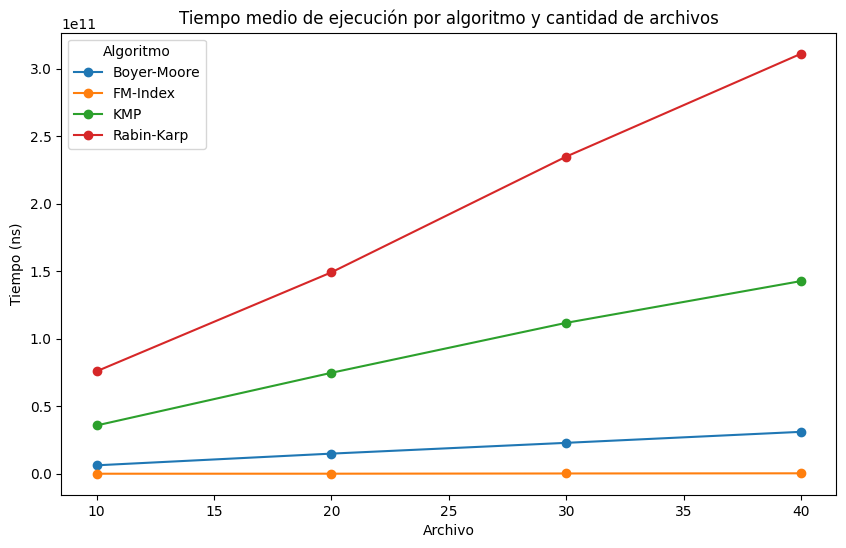

In [113]:
#  Algoritmo;Archivos;Cantidad;Patrones;Tiempo_Promedio(ns);Varianza(ns)

tabla_archivos = r_archivos.pivot_table(columns='Algoritmo', index='Cantidad', values='Tiempo_Promedio(ns)', aggfunc='mean')

tabla_archivos = tabla_archivos.rename(columns={
    'Robin-Karp': 'Rabin-Karp',
})

tabla_archivos.plot(
    kind='line',
    title='Tiempo medio de ejecución por algoritmo y cantidad de archivos',
    xlabel='Archivo',
    ylabel='Tiempo (ns)',
    figsize=(10, 6),
    marker='o',         # Opcional: añade puntos para facilitar la lectura
    grid=False           # Opcional: agrega una cuadrícula
)

<Axes: title={'center': 'Tiempo medio de ejecución por algoritmo y cantidad de patrones'}, xlabel='Cantidad de patrones', ylabel='Tiempo (ns)'>

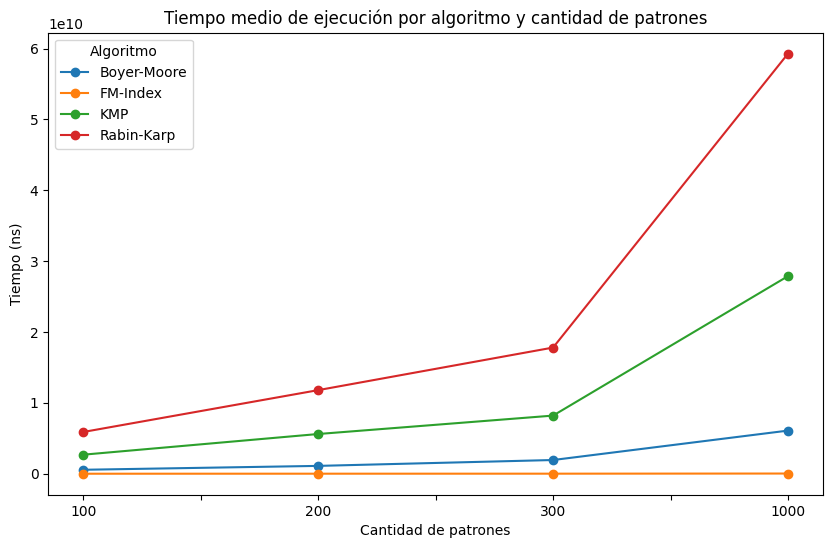

In [114]:
# Algoritmo;Archivos;Cantidad;Patrones;Tiempo_Promedio(ns);Varianza(ns)
tabla_patrones = r_patrones.pivot_table(columns='Algoritmo', index='Patrones', values='Tiempo_Promedio(ns)', aggfunc='mean')
tabla_patrones = tabla_patrones.rename(index={
    'patrones1_100_Existente': '100',
    'patrones2_200_Existente': '200',
    'patrones3_300_Existente': '300',
    'patrones4_1000_Existente':'1000',
})

tabla_patrones = tabla_patrones.rename(columns={
    'Robin-Karp': 'Rabin-Karp',
})

tabla_patrones.plot(
    kind='line',
    title='Tiempo medio de ejecución por algoritmo y cantidad de patrones',
    xlabel='Cantidad de patrones',
    ylabel='Tiempo (ns)',
    figsize=(10, 6),
    marker='o',         # Opcional: añade puntos para facilitar la lectura
    grid=False           # Opcional: agrega una cuadrícula
)

<Axes: title={'center': 'Tiempo medio de creación de estructura de FM-Index por cantidad de archivos'}, xlabel='Archivo', ylabel='Tiempo (ns)'>

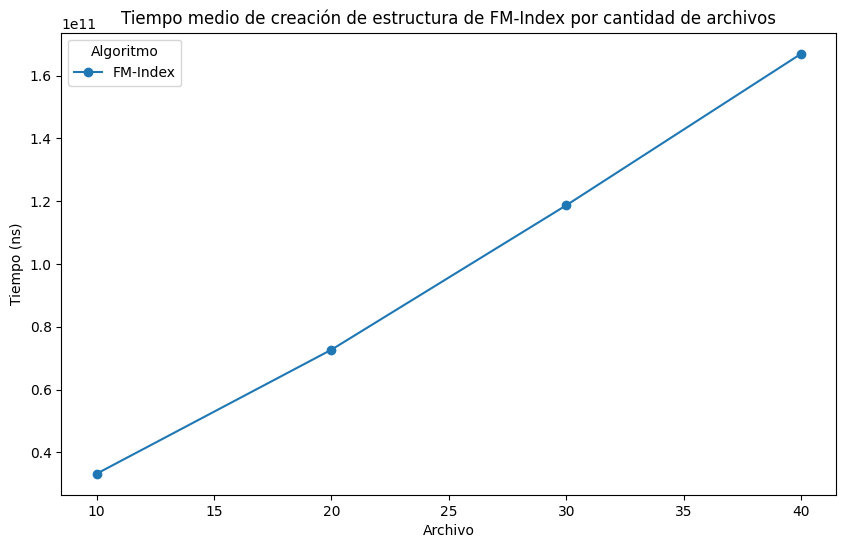

In [115]:
table_tiempo_creacion = r_tiempo_creacion_archivos.pivot_table(columns='Algoritmo', index='Cantidad', values='Tiempo_Promedio(ns)', aggfunc='mean')

table_tiempo_creacion.plot(
    kind='line',
    title='Tiempo medio de creación de estructura de FM-Index por cantidad de archivos',
    xlabel='Archivo',
    ylabel='Tiempo (ns)',
    figsize=(10, 6),
    marker='o',       
)  # Opcional: añade puntos para facilitar la lectura

<Axes: title={'center': 'Tiempo medio de ejecución por algoritmo y cantidad de archivos más el tiempo de creación'}, xlabel='Archivo', ylabel='Tiempo (ns)'>

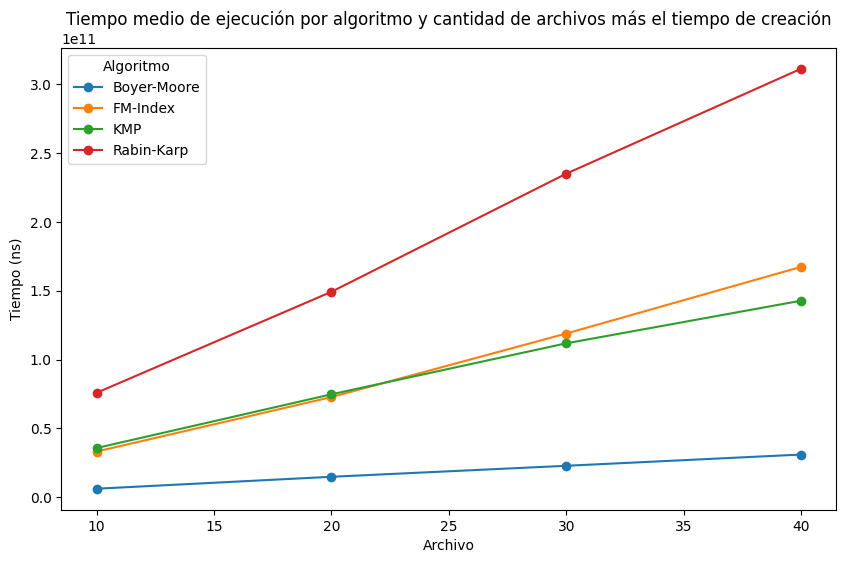

In [120]:
# tiempo tabla archivos + tiempo de creacion

tabla_archivos = r_archivos.pivot_table(columns='Algoritmo', index='Cantidad', values='Tiempo_Promedio(ns)', aggfunc='mean')

tabla_archivos['FM-Index'] = tabla_archivos['FM-Index'] + table_tiempo_creacion['FM-Index']

tabla_archivos = tabla_archivos.rename(columns={
    'Robin-Karp': 'Rabin-Karp',
})
tabla_archivos.plot(
    kind='line',
    title='Tiempo medio de ejecución por algoritmo y cantidad de archivos más el tiempo de creación',
    xlabel='Archivo',
    ylabel='Tiempo (ns)',
    figsize=(10, 6),
    marker='o',         # Opcional: añade puntos para facilitar la lectura
    grid=False,         # Opcional: agrega una cuadrícula
)